In [1]:
import os
import matplotlib.pyplot as plt
import cv2
import numpy as np
import random
from glob import glob

In [3]:
def image_grids(image, N):
    """
    Splits the given image into N x N grids.

    Parameters:
        image (numpy.ndarray): The input image loaded with OpenCV.
        N (int): Number of rows and columns to split the image into.

    Returns:
        grids (list): A list of grid cells (as image crops).
    """
    if image is None:
        raise ValueError("The provided image is None.")
    
    height, width = image.shape[:2]

    grid_h = height // N
    grid_w = width // N

    grids = []

    for i in range(N):
        for j in range(N):
            top = i * grid_h
            left = j * grid_w
            bottom = (i + 1) * grid_h if i < N - 1 else height
            right = (j + 1) * grid_w if j < N - 1 else width

            grid = image[top:bottom, left:right]
            grids.append(grid)

    return grids


In [5]:
imgs_folder  = '../filters-results/gatos'

In [21]:
img_paths = glob(imgs_folder + "/*.png")

In [23]:
#imgs_bgr = [cv2.imread(i) for i in img_paths]
imgs_rgb = [cv2.cvtColor(img,cv2.COLOR_BGR2RGB) for img in imgs_bgr ]

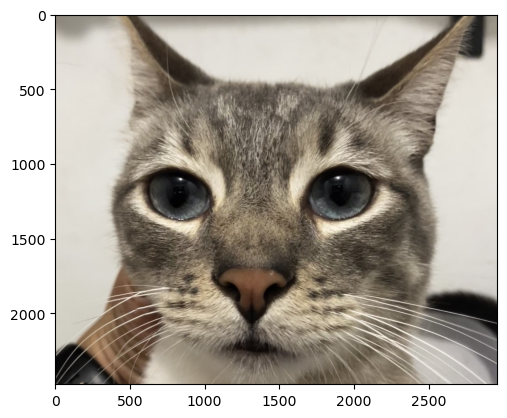

In [31]:
plt.imshow(imgs_rgb[3])

In [160]:
side = 23
boxed_list = [image_grids(i,side) for i in imgs_rgb ]

combined = []
box_slct = 0
imgqty = len(boxed_list)
for i in range(side ** 2):
    combined.append(boxed_list[box_slct][i])
    box_slct+=1
    if not box_slct % 4:
        box_slct = 0

sq = [combined[i * side:(i + 1) * side] for i in range(side)]
v = []
for h in sq:
    v.append(np.hstack(h))
j = np.vstack(v) 

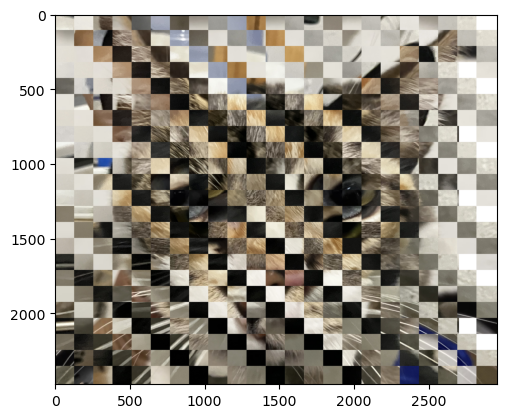

In [162]:
plt.imshow(j)

In [92]:
j_bgr = cv2.cvtColor(j,cv2.COLOR_RGB2BGR)
out_folder  = '../filters-results/boxes'
outf =  f"Boxed_{SIDE}_{f}"
of = os.path.join(out_folder, outf)
cv2.imwrite(of, j_bgr)

NameError: name 'f' is not defined